In [45]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

df = pd.read_csv("data2.csv")
data_km = df.copy()

# Không dùng nhãn
df_km = data_km.drop(columns=['Purchase_Intent'], errors='ignore')

# Drop ID / time
df_km = df_km.drop(columns=['Customer_ID', 'Time_of_Purchase', 'Location'], errors='ignore')

# Boolean mapping RÕ RÀNG
bool_map = {'TRUE': 1, 'FALSE': 0, True: 1, False: 0}
for col in ['Discount_Used', 'Customer_Loyalty_Program_Member']:
    if col in df_km.columns:
        df_km[col] = df_km[col].map(bool_map)

# Chia nhóm feature
ordinal_cols = [
    'Income_Level', 'Education_Level',
    'Social_Media_Influence', 'Discount_Sensitivity',
    'Engagement_with_Ads'
]

nominal_cols = [
    'Gender', 'Marital_Status', 'Occupation',
    'Purchase_Category', 'Purchase_Channel',
    'Device_Used_for_Shopping', 'Payment_Method',
    'Shipping_Preference'
]

numeric_cols = [
    'Age', 'Frequency_of_Purchase', 'Brand_Loyalty',
    'Product_Rating', 'Time_Spent_on_Product_Research(hours)',
    'Return_Rate', 'Customer_Satisfaction', 'Time_to_Decision'
]

# Ordinal order
ordinal_orders = [
    ['Low', 'Middle', 'High'],
    ['High School', "Bachelor's", "Master's"],
    ['None', 'Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High']
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                categories=ordinal_orders,
                handle_unknown='use_encoded_value',
                unknown_value=-1
            )),
            ('scaler', StandardScaler())
        ]), ordinal_cols),
    ]
)

X_km = preprocessor.fit_transform(df_km)

# If sparse matrix -> convert to dense numpy array
if hasattr(X_km, 'toarray'):
    X_km = X_km.toarray()

# Get feature names (supports sklearn >=1.0), fallback for older versions
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num' or name == 'ord':
            feature_names.extend(cols)
        elif name == 'nom':
            try:
                feature_names.extend(trans.get_feature_names_out(cols))
            except Exception:
                # fallback: use column name prefix + original col name
                for c in cols:
                    feature_names.append(f"{c}")

# Simplify names if they contain transformer prefixes like 'num__Age' or 'nom__Gender_Female'
feature_names = [fn.split('__')[-1] for fn in feature_names]

X_km = pd.DataFrame(X_km, columns=feature_names)

In [47]:
inertias = []
K_range = range(2, 11)  # thử từ 2 → 10

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_km)
    inertias.append(km.inertia_)


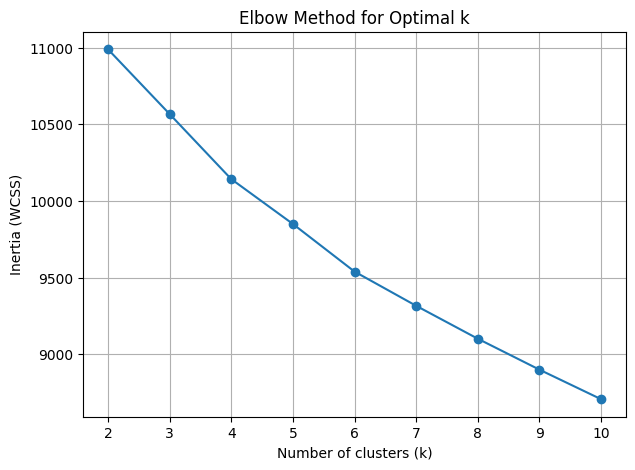

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑")
print("-" * 55)

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_k = kmeans.fit_predict(X_km)

    sil = silhouette_score(X_km, labels_k)
    dbi = davies_bouldin_score(X_km, labels_k)
    chi = calinski_harabasz_score(X_km, labels_k)

    print(f"{k:2d} | {sil:.3f}         | {dbi:.3f}              | {chi:.1f}")

k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑
-------------------------------------------------------
 2 | 0.085         | 3.269              | 91.8
 3 | 0.067         | 3.134              | 67.6
 4 | 0.068         | 3.171              | 60.8
 5 | 0.063         | 2.831              | 54.3
 6 | 0.067         | 2.930              | 51.3
 7 | 0.065         | 2.559              | 47.7
 8 | 0.065         | 2.512              | 45.1


In [50]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_km)

print("Silhouette score:", silhouette_score(X_km, labels))

Silhouette score: 0.0666629955959097


In [51]:
feature_importance = {}

for i, col in enumerate(X_km.columns):
    cluster_means = []
    for c in np.unique(labels):
        cluster_means.append(X_km.loc[labels == c, col].mean())
    
    feature_importance[col] = np.var(cluster_means)

importance_series = (
    pd.Series(feature_importance)
    .sort_values(ascending=False)
)


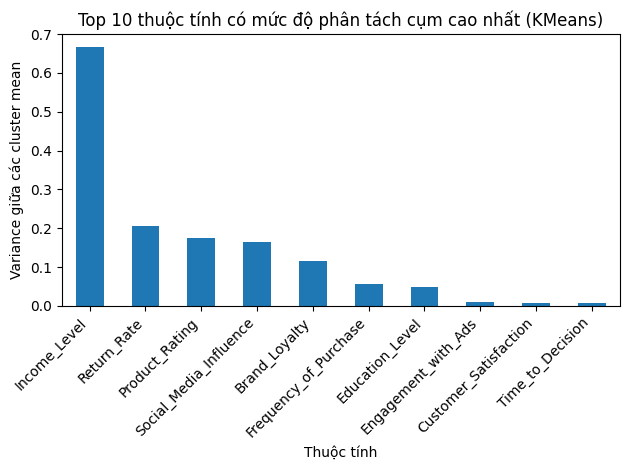

In [52]:

import matplotlib.pyplot as plt

# Lấy top 10 feature
top_n = 10
top_features = importance_series.head(top_n)

plt.figure()
top_features.plot(kind="bar")
plt.title("Top 10 thuộc tính có mức độ phân tách cụm cao nhất (KMeans)")
plt.xlabel("Thuộc tính")
plt.ylabel("Variance giữa các cluster mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [53]:
importance_series.head(10)

Income_Level              0.667270
Return_Rate               0.205457
Product_Rating            0.174650
Social_Media_Influence    0.163808
Brand_Loyalty             0.115173
Frequency_of_Purchase     0.056255
Education_Level           0.047940
Engagement_with_Ads       0.009507
Customer_Satisfaction     0.008120
Time_to_Decision          0.007120
dtype: float64

In [54]:
top_features = importance_series.head(5).index.tolist()
print("Selected features:", top_features)

X_selected = X_km[top_features]


Selected features: ['Income_Level', 'Return_Rate', 'Product_Rating', 'Social_Media_Influence', 'Brand_Loyalty']


In [55]:
# Evaluate clustering metrics on selected features (after feature selection)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ (on X_selected)")
print("-" * 70)
for k in range(2,9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(X_selected)

    sil = silhouette_score(X_selected, labels_k)
    dbi = davies_bouldin_score(X_selected, labels_k)
    chi = calinski_harabasz_score(X_selected, labels_k)

    print(f"{k:2d} | {sil:.3f}         | {dbi:.3f}              | {chi:.1f}")

k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ (on X_selected)
----------------------------------------------------------------------
 2 | 0.209         | 1.948              | 249.7
 3 | 0.204         | 1.732              | 218.6
 4 | 0.181         | 1.682              | 192.9
 5 | 0.189         | 1.671              | 182.6
 6 | 0.212         | 1.656              | 180.3
 7 | 0.211         | 1.541              | 176.0
 8 | 0.213         | 1.498              | 172.3


In [56]:
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_selected)
    inertias.append(km.inertia_)


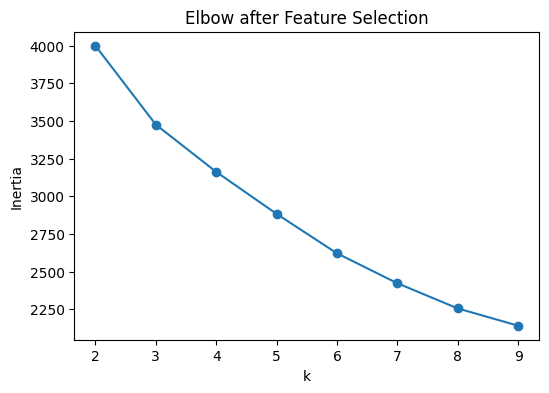

In [57]:
plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow after Feature Selection')
plt.show()


In [58]:
k1 = 3
kmeans_final = KMeans(n_clusters=k1, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_selected)

print("Final silhouette score:", silhouette_score(X_selected, labels_final))


Final silhouette score: 0.20375138362177955


In [59]:
data_clustered = df.copy()
data_clustered['Cluster'] = labels_final


In [60]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels_final


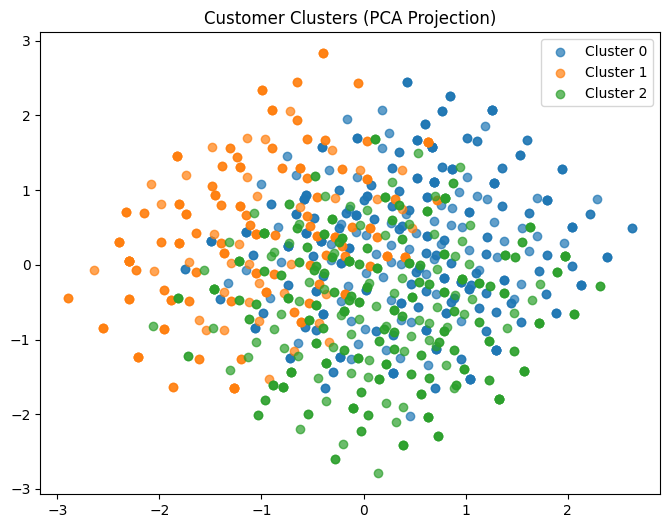

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for c in np.unique(labels_final):
    plt.scatter(
        pca_df[pca_df['Cluster']==c]['PC1'],
        pca_df[pca_df['Cluster']==c]['PC2'],
        label=f'Cluster {c}',
        alpha=0.7
    )

plt.legend()
plt.title('Customer Clusters (PCA Projection)')
plt.show()


In [62]:
# Lấy các feature đã chọn từ dữ liệu đã tiền xử lý (tồn tại trong `data_km`)
available_features = [f for f in top_features if f in data_km.columns]
missing = [f for f in top_features if f not in data_km.columns]
if missing:
    print("Warning: những feature sau không có trong dữ liệu đã tiền xử lý và sẽ bị bỏ qua:", missing)

export_df = data_km[available_features].copy()

# Nếu muốn giữ các cột định danh ban đầu (nếu có)
id_cols = [c for c in ['Customer_ID','Time_of_Purchase'] if c in df.columns]
if id_cols:
    export_df = pd.concat([df[id_cols].reset_index(drop=True), export_df.reset_index(drop=True)], axis=1)

# Gắn nhãn cluster (đảm bảo cùng chiều dài)
export_df['Cluster'] = labels_final

# Xuất ra file CSV
export_df.to_csv('customer_clusters_selected_features.csv', index=False)
print("Exported: customer_clusters_selected_features.csv")

Exported: customer_clusters_selected_features.csv
